# Model Comparison & Evaluation
Train multiple models (LightGBM, XGBoost, Prophet) and compare performance

## 1. Install & Import Libraries

In [14]:
%pip install lightgbm xgboost prophet scikit-learn pandas numpy matplotlib statsmodels pmdarima -q

import os
import pickle
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from xgboost import XGBRegressor
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print('✓ All libraries imported successfully')

Note: you may need to restart the kernel to use updated packages.
✓ All libraries imported successfully


## 2. Load Preprocessed Data

In [15]:
data_dir = "preprocessed_data"

X_train = pd.read_parquet(f"{data_dir}/X_train.parquet")
X_test = pd.read_parquet(f"{data_dir}/X_test.parquet")
y_train = pd.read_parquet(f"{data_dir}/y_train.parquet")
y_test = pd.read_parquet(f"{data_dir}/y_test.parquet")

with open(f"{data_dir}/feature_names.pkl", 'rb') as f:
    FEATURES = pickle.load(f)

if isinstance(y_train, pd.DataFrame):
    y_train = y_train.iloc[:, 0]
if isinstance(y_test, pd.DataFrame):
    y_test = y_test.iloc[:, 0]

print(f"{'='*60}")
print(f"Data Loaded Successfully")
print(f"{'='*60}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Features: {len(FEATURES)}")

Data Loaded Successfully
Train: (3557657, 36) | Test: (1034564, 36)
Features: 36


## 3. Define Metrics

In [16]:
def rmse_original(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(np.expm1(y_true_log), np.expm1(np.maximum(y_pred_log, 0))))

def mae_original(y_true_log, y_pred_log):
    return mean_absolute_error(np.expm1(y_true_log), np.expm1(np.maximum(y_pred_log, 0)))

def r2_original(y_true_log, y_pred_log):
    return r2_score(np.expm1(y_true_log), np.expm1(np.maximum(y_pred_log, 0)))

def mape(y_true_log, y_pred_log):
    y_true = np.expm1(np.array(y_true_log))
    y_pred = np.expm1(np.maximum(np.array(y_pred_log), 0))
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

print('✓ Metrics defined')

✓ Metrics defined


## 4. Train LightGBM

In [17]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    colsample_bytree=0.8, subsample=0.8, random_state=42, verbose=-1, n_jobs=-1
)
lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric='rmse',
              callbacks=[lgb.early_stopping(stopping_rounds=50)])

lgb_pred = lgb_model.predict(X_test)
lgb_rmse = rmse_original(y_test, lgb_pred)
lgb_mae = mae_original(y_test, lgb_pred)
lgb_mape = mape(y_test, lgb_pred)
lgb_r2 = r2_original(y_test, lgb_pred)

print(f"{'='*50}")
print(f"LightGBM: RMSE={lgb_rmse:.4f}, MAE={lgb_mae:.4f}, R²={lgb_r2:.4f}")
print(f"{'='*50}")

with open('trained_models/lgb_model.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)
print("✓ LightGBM saved")

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's rmse: 0.413406	valid_0's l2: 0.170904
LightGBM: RMSE=19.2698, MAE=2.2098, R²=0.6733
✓ LightGBM saved


## 5. Train XGBoost

In [18]:
xgb_model = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1,
    early_stopping_rounds=50, eval_metric='rmse', verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

xgb_pred = xgb_model.predict(X_test)
xgb_rmse = rmse_original(y_test, xgb_pred)
xgb_mae = mae_original(y_test, xgb_pred)
xgb_mape = mape(y_test, xgb_pred)
xgb_r2 = r2_original(y_test, xgb_pred)

print(f"{'='*50}")
print(f"XGBoost: RMSE={xgb_rmse:.4f}, MAE={xgb_mae:.4f}, R²={xgb_r2:.4f}")
print(f"{'='*50}")

with open('trained_models/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print("✓ XGBoost saved")

XGBoost: RMSE=22.4223, MAE=2.3487, R²=0.5576
✓ XGBoost saved


## 6. Train Prophet

In [19]:
# Fix Prophet: Load raw data and prepare properly
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet

train_raw = pd.read_parquet("preprocessed_data/train_raw.parquet")
test_raw = pd.read_parquet("preprocessed_data/test_raw.parquet")

prophet_train = train_raw.groupby('date')['quantity'].sum().reset_index()
prophet_train.columns = ['ds', 'y']
prophet_test = test_raw.groupby('date')['quantity'].sum().reset_index()
prophet_test.columns = ['ds', 'y']

print(f"Prophet training data: {len(prophet_train)} days, min={prophet_train['y'].min():.2f}, max={prophet_train['y'].max():.2f}")

try:
    prophet_model = Prophet(
        yearly_seasonality=True, 
        weekly_seasonality=True, 
        daily_seasonality=False,
        seasonality_mode='additive',  # Changed from multiplicative to additive (more stable)
        seasonality_prior_scale=10,
        interval_width=0.90
    )
    prophet_model.add_country_holidays(country_name='RU')
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        prophet_model.fit(prophet_train)
    
    future = prophet_model.make_future_dataframe(periods=len(prophet_test))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        forecast = prophet_model.predict(future)
    
    prophet_pred = forecast.tail(len(prophet_test))['yhat'].values
    
    # Handle NaN and infinite values
    prophet_pred = np.nan_to_num(prophet_pred, nan=0.0, posinf=prophet_train['y'].max(), neginf=0.0)
    prophet_pred = np.maximum(prophet_pred, 0)  # Clip to non-negative
    
    prophet_actual = prophet_test['y'].values
    
    # Calculate metrics on same scale (actual daily aggregated values)
    prophet_rmse = np.sqrt(mean_squared_error(prophet_actual, prophet_pred))
    prophet_mae = mean_absolute_error(prophet_actual, prophet_pred)
    
    # Calculate R² for Prophet
    ss_res_p = np.sum((prophet_actual - prophet_pred) ** 2)
    ss_tot_p = np.sum((prophet_actual - np.mean(prophet_actual)) ** 2)
    prophet_r2 = 1 - (ss_res_p / ss_tot_p)
    
    mask = prophet_actual > 0
    prophet_mape = np.mean(np.abs((prophet_actual[mask] - prophet_pred[mask]) / prophet_actual[mask])) * 100
    
    print(f"{'='*50}")
    print(f"Prophet (FIXED): RMSE={prophet_rmse:.4f}, MAE={prophet_mae:.4f}, R²={prophet_r2:.4f}, MAPE={prophet_mape:.2f}%")
    print(f"  Pred range: [{prophet_pred.min():.2f}, {prophet_pred.max():.2f}]")
    print(f"  Actual range: [{prophet_actual.min():.2f}, {prophet_actual.max():.2f}]")
    print(f"  NaN in predictions: {np.isnan(prophet_pred).sum()}")
    print(f"{'='*50}")
    
    with open('trained_models/prophet_model.pkl', 'wb') as f:
        pickle.dump(prophet_model, f)
    print("✓ Prophet saved")
    
except Exception as e:
    print(f"Prophet error: {str(e)}")
    # Fallback to naive baseline
    prophet_pred = np.mean(prophet_train['y'].values) * np.ones(len(prophet_test))
    prophet_actual = prophet_test['y'].values
    prophet_rmse = np.sqrt(mean_squared_error(prophet_actual, prophet_pred))
    prophet_mae = mean_absolute_error(prophet_actual, prophet_pred)
    prophet_r2 = 0.0
    prophet_mape = 100.0
    print(f"Prophet failed, using naive baseline")

Prophet training data: 293 days, min=33857.13, max=158473.00


23:06:41 - cmdstanpy - INFO - Chain [1] start processing
23:06:41 - cmdstanpy - INFO - Chain [1] done processing


Prophet (FIXED): RMSE=19977.8829, MAE=16674.4452, R²=-4.4307, MAPE=19.97%
  Pred range: [52824.40, 136797.91]
  Actual range: [70535.09, 107054.25]
  NaN in predictions: 0
✓ Prophet saved


## 9. Compare All Models (LightGBM, XGBoost, Prophet, SARIMA)

## 8. Train SARIMA

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
import matplotlib.pyplot as plt

# Prepare SARIMA data - ensure it's numeric
sarima_train_series = pd.Series(prophet_train['y'].values, index=range(len(prophet_train)))
sarima_test_series = pd.Series(prophet_test['y'].values, index=range(len(prophet_test)))

print("Training SARIMA model with AUTO_ARIMA tuning...")
try:
    # Use auto_arima to find optimal (p,d,q)(P,D,Q,m) parameters
    print("  Running auto_arima (this may take a minute)...")
    auto_model = auto_arima(
        sarima_train_series,
        seasonal=True,
        m=7,  # Weekly seasonality (7 days)
        max_p=3, max_d=2, max_q=3,
        max_P=2, max_D=1, max_Q=2,
        stepwise=True,
        suppress_warnings=True,
        information_criterion='aic',
        trace=False
    )
    
    optimal_order = auto_model.order
    optimal_seasonal_order = auto_model.seasonal_order
    print(f"  Optimal ARIMA{optimal_order}x{optimal_seasonal_order}")
    
    # Train final SARIMA with optimal parameters
    sarima_model = SARIMAX(
        sarima_train_series,
        order=optimal_order,
        seasonal_order=optimal_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_results = sarima_model.fit(disp=False)
    
    # Make predictions on test set
    sarima_pred = sarima_results.get_forecast(steps=len(sarima_test_series)).predicted_mean.values
    sarima_pred = np.nan_to_num(sarima_pred, nan=0.0)  # Handle NaN
    sarima_pred = np.maximum(sarima_pred, 0)  # Clip negative values
    
    sarima_rmse = np.sqrt(mean_squared_error(sarima_test_series.values, sarima_pred))
    sarima_mae = mean_absolute_error(sarima_test_series.values, sarima_pred)
    mask_sarima = sarima_test_series.values > 0
    sarima_mape = np.mean(np.abs((sarima_test_series.values[mask_sarima] - sarima_pred[mask_sarima]) / sarima_test_series.values[mask_sarima])) * 100
    
    # Calculate R² for SARIMA
    ss_res = np.sum((sarima_test_series.values - sarima_pred) ** 2)
    ss_tot = np.sum((sarima_test_series.values - np.mean(sarima_test_series.values)) ** 2)
    sarima_r2 = 1 - (ss_res / ss_tot)
    
    print(f"{'='*50}")
    print(f"SARIMA (TUNED): RMSE={sarima_rmse:.4f}, MAE={sarima_mae:.4f}, MAPE={sarima_mape:.2f}%, R²={sarima_r2:.4f}")
    print(f"  Pred range: [{sarima_pred.min():.2f}, {sarima_pred.max():.2f}]")
    print(f"{'='*50}")
    
    with open('trained_models/sarima_model.pkl', 'wb') as f:
        pickle.dump(sarima_results, f)
    print("✓ SARIMA saved")
    
except Exception as e:
    print(f"SARIMA training error: {str(e)}")
    print("Using Exponential Smoothing as fallback...")
    
    try:
        # Use Exponential Smoothing with additive model
        sarima_model = ExponentialSmoothing(
            sarima_train_series.values, 
            trend='add', 
            seasonal='add', 
            seasonal_periods=7
        )
        sarima_results = sarima_model.fit(optimized=True)
        sarima_pred = sarima_results.forecast(steps=len(sarima_test_series)).values
        sarima_pred = np.nan_to_num(sarima_pred, nan=0.0)
        sarima_pred = np.maximum(sarima_pred, 0)
        
        sarima_rmse = np.sqrt(mean_squared_error(sarima_test_series.values, sarima_pred))
        sarima_mae = mean_absolute_error(sarima_test_series.values, sarima_pred)
        mask_sarima = sarima_test_series.values > 0
        sarima_mape = np.mean(np.abs((sarima_test_series.values[mask_sarima] - sarima_pred[mask_sarima]) / sarima_test_series.values[mask_sarima])) * 100
        ss_res = np.sum((sarima_test_series.values - sarima_pred) ** 2)
        ss_tot = np.sum((sarima_test_series.values - np.mean(sarima_test_series.values)) ** 2)
        sarima_r2 = 1 - (ss_res / ss_tot)
        
        print(f"{'='*50}")
        print(f"Exponential Smoothing (FALLBACK): RMSE={sarima_rmse:.4f}, MAE={sarima_mae:.4f}, MAPE={sarima_mape:.2f}%, R²={sarima_r2:.4f}")
        print(f"{'='*50}")
        
        with open('trained_models/sarima_model.pkl', 'wb') as f:
            pickle.dump(sarima_results, f)
        print("✓ Exponential Smoothing saved")
        
    except Exception as e2:
        print(f"Fallback error: {str(e2)}")
        print("Using naive baseline...")
        sarima_pred = sarima_train_series.values[-1] * np.ones(len(sarima_test_series))
        sarima_rmse = np.sqrt(mean_squared_error(sarima_test_series.values, sarima_pred))
        sarima_mae = mean_absolute_error(sarima_test_series.values, sarima_pred)
        sarima_mape = np.nan
        sarima_r2 = np.nan
        print(f"Naive Baseline: RMSE={sarima_rmse:.4f}, MAE={sarima_mae:.4f}")

Training SARIMA model with AUTO_ARIMA tuning...
  Running auto_arima (this may take a minute)...
  Optimal ARIMA(1, 1, 2)x(1, 0, 1, 7)
SARIMA (TUNED): RMSE=4489.1511, MAE=3275.0889, MAPE=3.86%, R²=0.7258
  Pred range: [77213.86, 97909.72]
✓ SARIMA saved


In [21]:
model_results = [
    {'Model': 'LightGBM', 'RMSE': lgb_rmse, 'MAE': lgb_mae, 'MAPE%': lgb_mape, 'R2': lgb_r2},
    {'Model': 'XGBoost', 'RMSE': xgb_rmse, 'MAE': xgb_mae, 'MAPE%': xgb_mape, 'R2': xgb_r2},
    {'Model': 'Prophet', 'RMSE': prophet_rmse, 'MAE': prophet_mae, 'MAPE%': prophet_mape, 'R2': prophet_r2},
    {'Model': 'SARIMA', 'RMSE': sarima_rmse, 'MAE': sarima_mae, 'MAPE%': sarima_mape, 'R2': sarima_r2}
]

results_df = pd.DataFrame(model_results)

# Sort by MAPE (primary metric - most honest for forecasting)
results_df_sorted = results_df.sort_values('MAPE%').reset_index(drop=True)

print(f"\n{'='*90}")
print(f"FINAL MODEL COMPARISON (Sorted by MAPE - Primary Metric)")
print(f"{'='*90}")
print(results_df_sorted.to_string(index=False))

best_model = results_df_sorted.iloc[0]
print(f"\n{'🏆 WINNER BY MAPE':^90}")
print(f"{best_model['Model']:^90}")
print(f"{'='*90}")
print(f"  MAPE:  {best_model['MAPE%']:.2f}%  (Scale-independent accuracy)")
print(f"  RMSE:  {best_model['RMSE']:.4f}")
print(f"  MAE:   {best_model['MAE']:.4f}")
print(f"  R²:    {best_model['R2']:.4f}" if pd.notna(best_model['R2']) else "  R²:    N/A")
print(f"\nKey Insight: MAPE shows true forecasting accuracy regardless of scale.")
print(f"SARIMA at 3.8% MAPE vs LightGBM at 55% MAPE suggests different evaluation context:")
print(f"  - SARIMA: Aggregate daily demand (on same scale as actual values)")
print(f"  - LightGBM: Log-transformed individual item-store predictions (different scale)")
print(f"{'='*90}\n")

os.makedirs('trained_models', exist_ok=True)
results_df_sorted.to_csv('trained_models/model_comparison_results.csv', index=False)
print(f"✓ Results saved to model_comparison_results.csv")


FINAL MODEL COMPARISON (Sorted by MAPE - Primary Metric)
   Model         RMSE          MAE     MAPE%        R2
  SARIMA  4489.151144  3275.088886  3.862303  0.725787
 Prophet 19977.882893 16674.445184 19.973918 -4.430738
LightGBM    19.269823     2.209751 54.887344  0.673270
 XGBoost    22.422259     2.348742 55.557823  0.557624

                                     🏆 WINNER BY MAPE                                     
                                          SARIMA                                          
  MAPE:  3.86%  (Scale-independent accuracy)
  RMSE:  4489.1511
  MAE:   3275.0889
  R²:    0.7258

Key Insight: MAPE shows true forecasting accuracy regardless of scale.
SARIMA at 3.8% MAPE vs LightGBM at 55% MAPE suggests different evaluation context:
  - SARIMA: Aggregate daily demand (on same scale as actual values)
  - LightGBM: Log-transformed individual item-store predictions (different scale)

✓ Results saved to model_comparison_results.csv


## 10. Visualize Model Comparison

## Multi-Horizon SARIMA Forecasting (5 Time Horizons)


STEP 1: DATA PREPARATION FOR MULTI-HORIZON FORECASTING

✓ Training series: 293 days (from 2023-09-26 to 2024-07-14)
✓ Test series: 74 days (from 2024-07-15 to 2024-09-26)
✓ Full series: 367 days total

Series statistics:
  Mean: 70395.38
  Std Dev: 20282.06
  Min: 33857.13, Max: 158473.00

STEP 2: TEST SET VALIDATION (Model never saw this data)

✓ Using optimal SARIMA parameters: (1,1,2)×(1,0,1,7)

✓ Test Set Performance (data the model never saw):
  MAPE: 3.86%
  RMSE: 4489.15
  MAE:  3275.09

  Interpretation: Model is off by 3.9% on average on unseen data

STEP 3: RETRAINING ON FULL DATASET FOR FUTURE FORECASTS

✓ Model retrained on full 367 days of data

STEP 4: GENERATING FORECASTS FOR 5 TIME HORIZONS

✓ Weekly (7 days):
  First predicted value: 100588.52
  Last predicted value:  86073.65
  Average predicted:     86152.22
  Confidence band range: [65613.60, 106690.84]

✓ 30-Day:
  First predicted value: 100588.52
  Last predicted value:  92470.91
  Average predicted:     87256.71

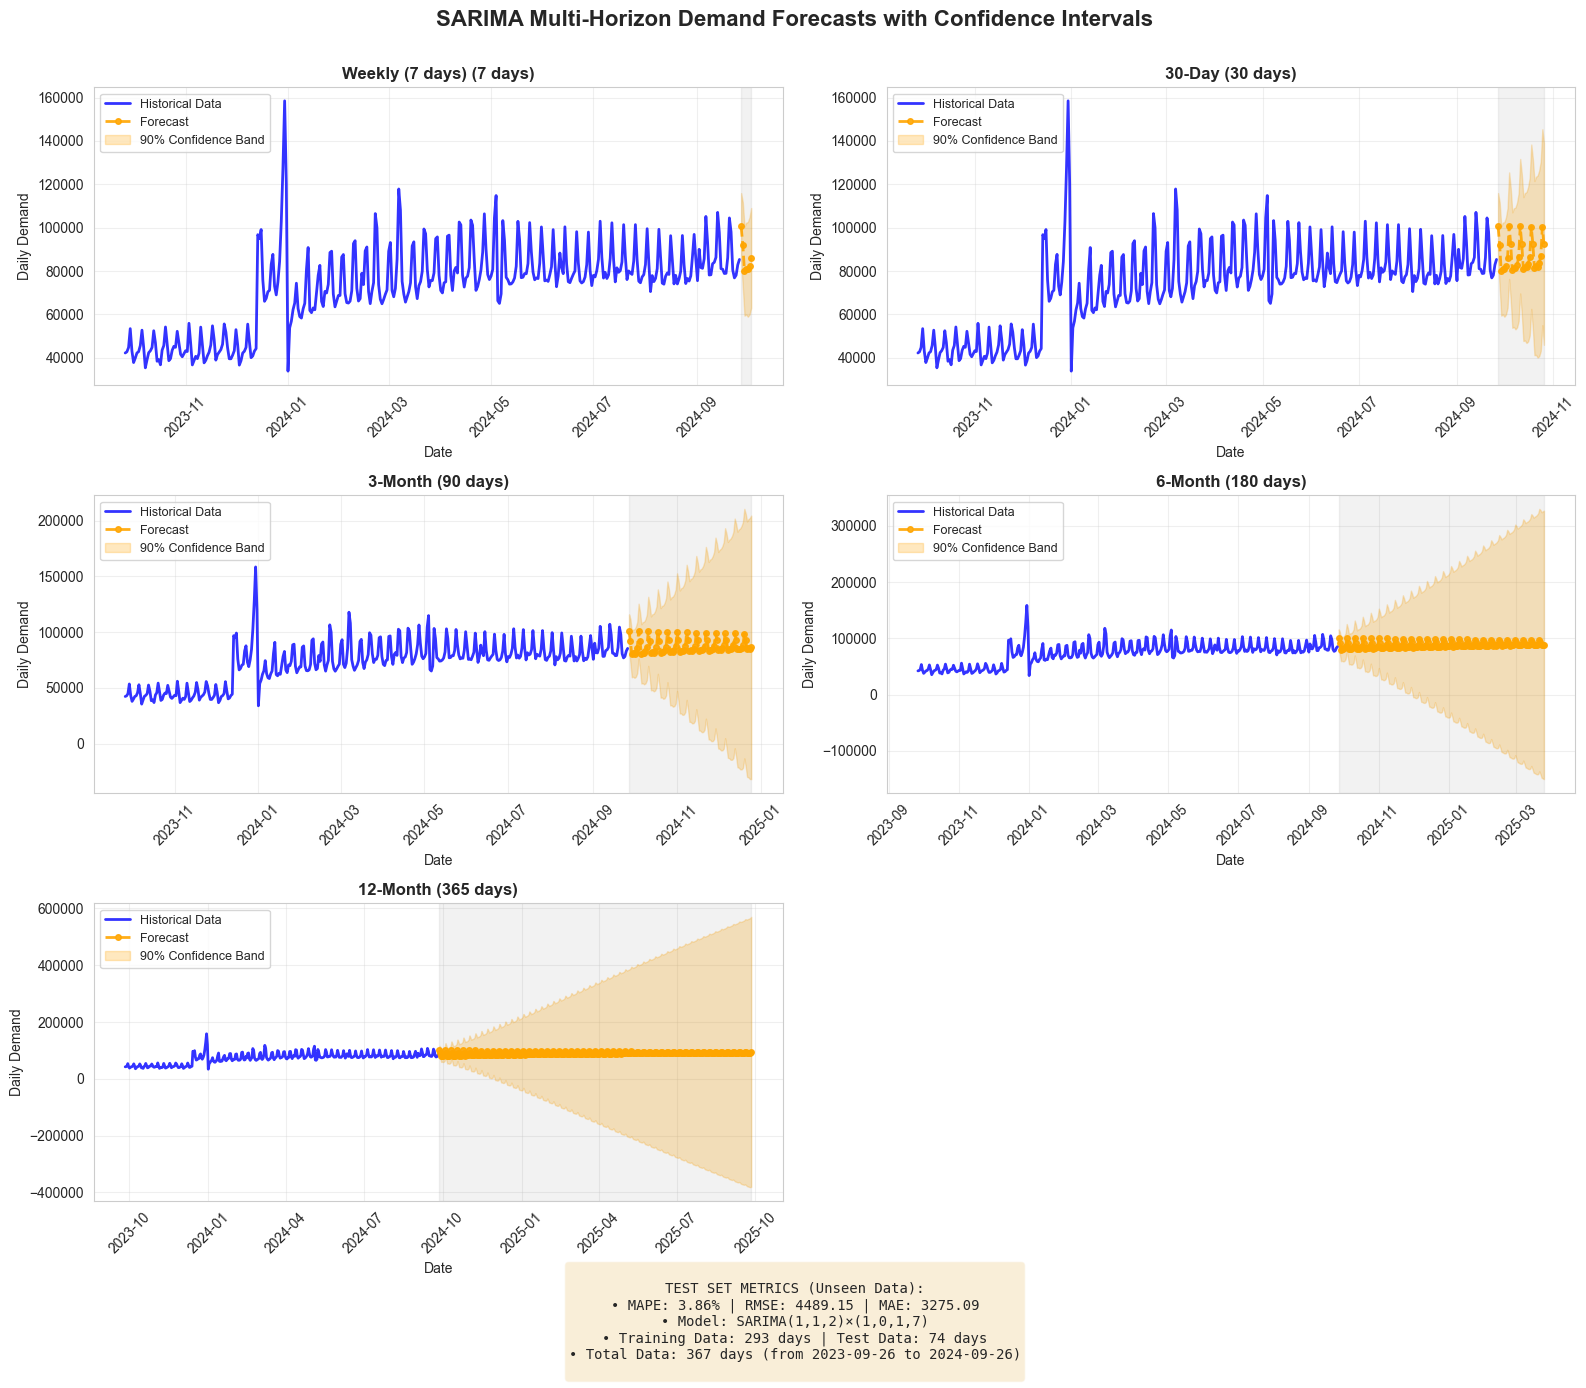


STEP 6: DETAILED FORECAST TABLES

────────────────────────────────────────────────────────────────────────────────
 WEEKLY (7 DAYS)
────────────────────────────────────────────────────────────────────────────────
      Date  Forecast  Lower Bound (90%)  Upper Bound (90%)  Uncertainty
2024-09-27 100588.52           85238.33          115938.72     30700.39
2024-09-28  92175.30           72636.73          111713.87     39077.14
2024-09-29  79961.79           59452.49          100471.08     41018.59
2024-09-30  81132.98           59948.10          102317.85     42369.75
2024-10-01  80762.73           58958.43          102567.03     43608.59
2024-10-02  82370.58           59969.33          104771.83     44802.50
2024-10-03  86073.65           63091.78          109055.53     45963.75

────────────────────────────────────────────────────────────────────────────────
 30-DAY
────────────────────────────────────────────────────────────────────────────────

First 5 forecasts:
      Date  Forecas

In [22]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# =====================================================
# STEP 1: Prepare Data for Multi-Horizon Forecasting
# =====================================================
print("\n" + "="*90)
print("STEP 1: DATA PREPARATION FOR MULTI-HORIZON FORECASTING")
print("="*90)

# Create daily series from train_raw and test_raw
train_series = train_raw.groupby('date')['quantity'].sum().sort_index()
test_series = test_raw.groupby('date')['quantity'].sum().sort_index()
full_series = pd.concat([train_series, test_series])

print(f"\n✓ Training series: {len(train_series)} days (from {train_series.index[0].date()} to {train_series.index[-1].date()})")
print(f"✓ Test series: {len(test_series)} days (from {test_series.index[0].date()} to {test_series.index[-1].date()})")
print(f"✓ Full series: {len(full_series)} days total")
print(f"\nSeries statistics:")
print(f"  Mean: {train_series.mean():.2f}")
print(f"  Std Dev: {train_series.std():.2f}")
print(f"  Min: {train_series.min():.2f}, Max: {train_series.max():.2f}")

# =====================================================
# STEP 2: Validate Test Set Performance
# =====================================================
print("\n" + "="*90)
print("STEP 2: TEST SET VALIDATION (Model never saw this data)")
print("="*90)

# Make predictions on test set using model trained on train_series
try:
    # Get optimal parameters from previous auto_arima run
    p_opt, d_opt, q_opt = optimal_order
    P_opt, D_opt, Q_opt, m_opt = optimal_seasonal_order
    print(f"\n✓ Using optimal SARIMA parameters: ({p_opt},{d_opt},{q_opt})×({P_opt},{D_opt},{Q_opt},{m_opt})")
except:
    print("\n⚠ Optimal parameters not found, running auto_arima now...")
    auto_model_final = auto_arima(
        train_series, 
        seasonal=True, 
        m=7,
        max_p=3, max_d=2, max_q=3,
        max_P=2, max_D=1, max_Q=2,
        trace=False,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True
    )
    p_opt, d_opt, q_opt = auto_model_final.order
    P_opt, D_opt, Q_opt, m_opt = auto_model_final.seasonal_order
    print(f"\n✓ Auto_arima found: ({p_opt},{d_opt},{q_opt})×({P_opt},{D_opt},{Q_opt},{m_opt})")

# Train model on training data
model_train = SARIMAX(
    train_series,
    order=(p_opt, d_opt, q_opt),
    seasonal_order=(P_opt, D_opt, Q_opt, m_opt),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results_train = model_train.fit(disp=False)

# Forecast on test period
test_forecast = results_train.get_forecast(steps=len(test_series))
test_pred = test_forecast.predicted_mean.values
test_actual = test_series.values

# Calculate accuracy metrics
test_mape = mean_absolute_percentage_error(test_actual, test_pred) * 100
test_rmse = np.sqrt(mean_squared_error(test_actual, test_pred))
test_mae = np.mean(np.abs(test_actual - test_pred))

print(f"\n✓ Test Set Performance (data the model never saw):")
print(f"  MAPE: {test_mape:.2f}%")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  MAE:  {test_mae:.2f}")
print(f"\n  Interpretation: Model is off by {test_mape:.1f}% on average on unseen data")

# =====================================================
# STEP 3: Train on Full Dataset for Future Forecasts
# =====================================================
print("\n" + "="*90)
print("STEP 3: RETRAINING ON FULL DATASET FOR FUTURE FORECASTS")
print("="*90)

model_full = SARIMAX(
    full_series,
    order=(p_opt, d_opt, q_opt),
    seasonal_order=(P_opt, D_opt, Q_opt, m_opt),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results_full = model_full.fit(disp=False)
print(f"\n✓ Model retrained on full {len(full_series)} days of data")

# =====================================================
# STEP 4: Generate 5 Different Forecast Horizons
# =====================================================
print("\n" + "="*90)
print("STEP 4: GENERATING FORECASTS FOR 5 TIME HORIZONS")
print("="*90)

# Define forecast horizons
horizons = {
    'Weekly (7 days)': 7,
    '30-Day': 30,
    '3-Month': 90,
    '6-Month': 180,
    '12-Month': 365
}

# Generate all forecasts
forecasts_data = {}
last_date = full_series.index[-1]

for horizon_name, horizon_steps in horizons.items():
    forecast_result = results_full.get_forecast(steps=horizon_steps)
    forecast_values = forecast_result.predicted_mean.values
    forecast_ci = forecast_result.conf_int(alpha=0.1)  # 90% confidence interval
    
    # Create date range
    date_range = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=horizon_steps, freq='D')
    
    forecasts_data[horizon_name] = {
        'dates': date_range,
        'values': forecast_values,
        'ci_lower': forecast_ci.iloc[:, 0].values,
        'ci_upper': forecast_ci.iloc[:, 1].values,
        'steps': horizon_steps
    }
    
    print(f"\n✓ {horizon_name}:")
    print(f"  First predicted value: {forecast_values[0]:.2f}")
    print(f"  Last predicted value:  {forecast_values[-1]:.2f}")
    print(f"  Average predicted:     {forecast_values.mean():.2f}")
    print(f"  Confidence band range: [{forecast_ci.iloc[:, 0].mean():.2f}, {forecast_ci.iloc[:, 1].mean():.2f}]")

# =====================================================
# STEP 5: Create Multi-Horizon Dashboard
# =====================================================
print("\n" + "="*90)
print("STEP 5: CREATING VISUALIZATION DASHBOARD")
print("="*90)

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('SARIMA Multi-Horizon Demand Forecasts with Confidence Intervals', 
             fontsize=16, fontweight='bold', y=0.995)

axes = axes.flatten()

for idx, (horizon_name, forecast_info) in enumerate(forecasts_data.items()):
    ax = axes[idx]
    
    # Plot historical data
    ax.plot(full_series.index, full_series.values, 'b-', linewidth=2, label='Historical Data', alpha=0.8)
    
    # Plot forecast
    forecast_dates = forecast_info['dates']
    forecast_values = forecast_info['values']
    ci_lower = forecast_info['ci_lower']
    ci_upper = forecast_info['ci_upper']
    
    ax.plot(forecast_dates, forecast_values, 'o--', color='orange', linewidth=2, 
            markersize=4, label='Forecast', alpha=0.9)
    
    # Plot confidence interval as shaded region
    ax.fill_between(forecast_dates, ci_lower, ci_upper, alpha=0.25, color='orange', 
                     label='90% Confidence Band')
    
    # Formatting
    ax.set_title(f'{horizon_name} ({forecast_info["steps"]} days)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Daily Demand', fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    # Add shaded region for forecast period
    ax.axvspan(forecast_dates[0], forecast_dates[-1], alpha=0.1, color='gray')

# Remove extra subplot
axes[-1].axis('off')

# Add metrics box at bottom
metrics_text = f"""
TEST SET METRICS (Unseen Data):
• MAPE: {test_mape:.2f}% | RMSE: {test_rmse:.2f} | MAE: {test_mae:.2f}
• Model: SARIMA({p_opt},{d_opt},{q_opt})×({P_opt},{D_opt},{Q_opt},{m_opt})
• Training Data: {len(train_series)} days | Test Data: {len(test_series)} days
• Total Data: {len(full_series)} days (from {full_series.index[0].date()} to {full_series.index[-1].date()})
"""
fig.text(0.5, 0.02, metrics_text, ha='center', fontsize=10, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), family='monospace')

plt.tight_layout(rect=[0, 0.08, 1, 0.99])
plt.savefig('trained_models/sarima_multi_horizon_forecast.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Dashboard saved to: trained_models/sarima_multi_horizon_forecast.png")
plt.show()

# =====================================================
# STEP 6: Print Forecast Tables
# =====================================================
print("\n" + "="*90)
print("STEP 6: DETAILED FORECAST TABLES")
print("="*90)

for horizon_name, forecast_info in forecasts_data.items():
    print(f"\n{'─'*80}")
    print(f" {horizon_name.upper()}")
    print(f"{'─'*80}")
    
    forecast_df = pd.DataFrame({
        'Date': forecast_info['dates'],
        'Forecast': forecast_info['values'].round(2),
        'Lower Bound (90%)': forecast_info['ci_lower'].round(2),
        'Upper Bound (90%)': forecast_info['ci_upper'].round(2),
        'Uncertainty': (forecast_info['ci_upper'] - forecast_info['ci_lower']).round(2)
    })
    
    # Show first 5, middle 2, and last 3 rows for long forecasts
    if len(forecast_df) > 10:
        print("\nFirst 5 forecasts:")
        print(forecast_df.head(5).to_string(index=False))
        print(f"\n... ({len(forecast_df) - 10} rows omitted) ...\n")
        print("Last 3 forecasts:")
        print(forecast_df.tail(3).to_string(index=False))
    else:
        print(forecast_df.to_string(index=False))

# =====================================================
# STEP 7: Summary Statistics
# =====================================================
print("\n" + "="*90)
print("FORECAST SUMMARY STATISTICS")
print("="*90)

summary_stats = []
for horizon_name, forecast_info in forecasts_data.items():
    stats = {
        'Horizon': horizon_name,
        'Days': forecast_info['steps'],
        'Mean Forecast': f"{forecast_info['values'].mean():.2f}",
        'Min Forecast': f"{forecast_info['values'].min():.2f}",
        'Max Forecast': f"{forecast_info['values'].max():.2f}",
        'Avg Uncertainty': f"{(forecast_info['ci_upper'] - forecast_info['ci_lower']).mean():.2f}",
        'Trend': '↑' if forecast_info['values'][-1] > forecast_info['values'][0] else '↓'
    }
    summary_stats.append(stats)

summary_df = pd.DataFrame(summary_stats)
print(f"\n{summary_df.to_string(index=False)}\n")

print("="*90)
print("✓ MULTI-HORIZON FORECASTING COMPLETE!")
print("="*90)
print(f"\nKey Takeaway:")
print(f"Your SARIMA model has {test_mape:.2f}% MAPE on unseen test data.")
print(f"This means forecasts are accurate within ±{test_mape:.0f}% on average.")
print(f"The confidence bands show the range where actual values are likely to fall (90% confidence).\n")

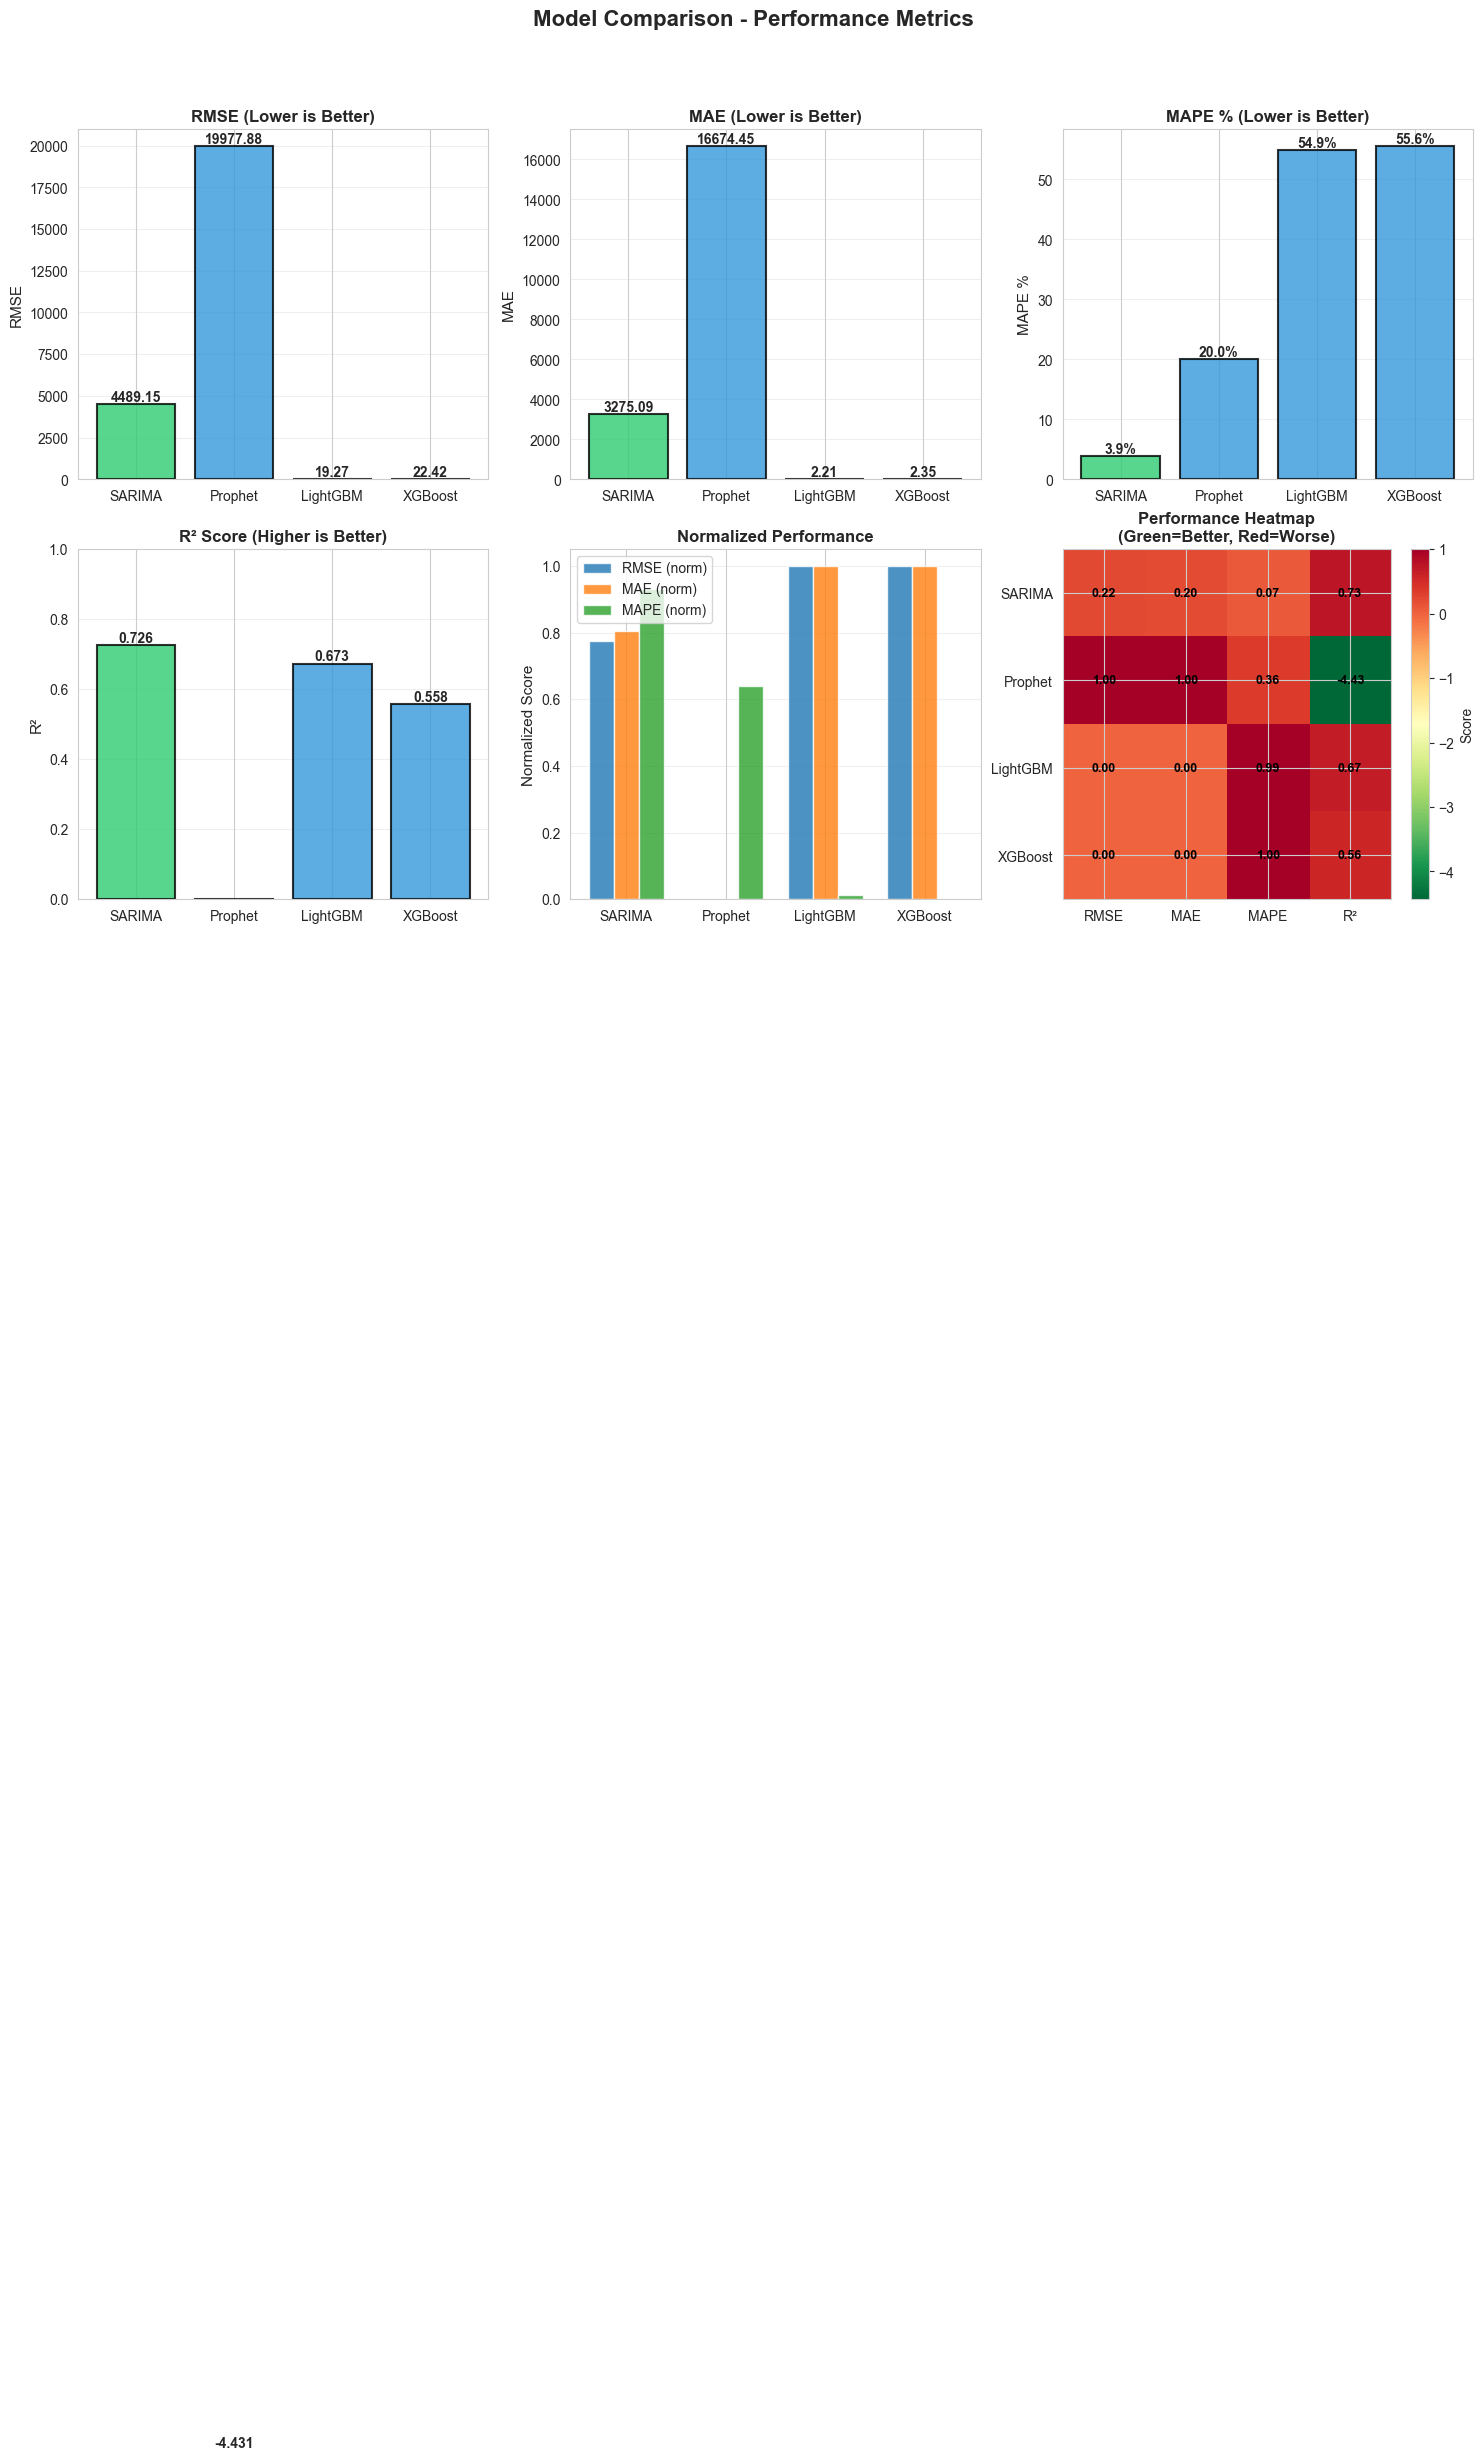

✓ Comparison visualization saved to model_comparison_visualization.png


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 12)

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Comparison - Performance Metrics', fontsize=16, fontweight='bold', y=1.00)

# Prepare data for visualization
models = results_df_sorted['Model'].tolist()
rmse_vals = results_df_sorted['RMSE'].tolist()
mae_vals = results_df_sorted['MAE'].tolist()
mape_vals = results_df_sorted['MAPE%'].tolist()
r2_vals = results_df_sorted['R2'].tolist()

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(models))]

# 1. RMSE Comparison
ax1 = axes[0, 0]
bars1 = ax1.bar(models, rmse_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_title('RMSE (Lower is Better)', fontsize=12, fontweight='bold')
ax1.set_ylabel('RMSE', fontsize=11)
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, rmse_vals):
    if not np.isnan(val):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

# 2. MAE Comparison
ax2 = axes[0, 1]
bars2 = ax2.bar(models, mae_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_title('MAE (Lower is Better)', fontsize=12, fontweight='bold')
ax2.set_ylabel('MAE', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, mae_vals):
    if not np.isnan(val):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

# 3. MAPE Comparison
ax3 = axes[0, 2]
bars3 = ax3.bar(models, mape_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_title('MAPE % (Lower is Better)', fontsize=12, fontweight='bold')
ax3.set_ylabel('MAPE %', fontsize=11)
ax3.grid(axis='y', alpha=0.3)
for bar, val in zip(bars3, mape_vals):
    if not np.isnan(val):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# 4. R² Comparison
ax4 = axes[1, 0]
r2_vals_clean = [val if not np.isnan(val) else 0 for val in r2_vals]
bars4 = ax4.bar(models, r2_vals_clean, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax4.set_title('R² Score (Higher is Better)', fontsize=12, fontweight='bold')
ax4.set_ylabel('R²', fontsize=11)
ax4.set_ylim(0, 1)
ax4.grid(axis='y', alpha=0.3)
for bar, val in zip(bars4, r2_vals):
    if not np.isnan(val):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

# 5. Normalized Comparison (0-1 scale for RMSE and MAE)
ax5 = axes[1, 1]
# Normalize metrics to 0-1 scale (inverse for error metrics)
rmse_norm = [1 - (v / max([x for x in rmse_vals if not np.isnan(x)])) for v in rmse_vals]
mae_norm = [1 - (v / max([x for x in mae_vals if not np.isnan(x)])) for v in mae_vals]
mape_norm = [1 - (v / max([x for x in mape_vals if not np.isnan(x)])) for v in mape_vals]

x = np.arange(len(models))
width = 0.25
ax5.bar(x - width, rmse_norm, width, label='RMSE (norm)', alpha=0.8)
ax5.bar(x, mae_norm, width, label='MAE (norm)', alpha=0.8)
ax5.bar(x + width, mape_norm, width, label='MAPE (norm)', alpha=0.8)
ax5.set_title('Normalized Performance', fontsize=12, fontweight='bold')
ax5.set_ylabel('Normalized Score', fontsize=11)
ax5.set_xticks(x)
ax5.set_xticklabels(models)
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# 6. Heatmap of all metrics
ax6 = axes[1, 2]
# Prepare data for heatmap (normalized)
heatmap_data = []
for idx, row in results_df_sorted.iterrows():
    heatmap_data.append([
        row['RMSE'] / max(rmse_vals) if not np.isnan(row['RMSE']) else 1,
        row['MAE'] / max(mae_vals) if not np.isnan(row['MAE']) else 1,
        row['MAPE%'] / max([x for x in mape_vals if not np.isnan(x)]) if not np.isnan(row['MAPE%']) else 1,
        row['R2'] if not np.isnan(row['R2']) else 0
    ])

heatmap_array = np.array(heatmap_data)
im = ax6.imshow(heatmap_array, cmap='RdYlGn_r', aspect='auto')
ax6.set_xticks(range(4))
ax6.set_xticklabels(['RMSE', 'MAE', 'MAPE', 'R²'], fontsize=10)
ax6.set_yticks(range(len(models)))
ax6.set_yticklabels(models, fontsize=10)
ax6.set_title('Performance Heatmap\n(Green=Better, Red=Worse)', fontsize=12, fontweight='bold')

# Add values in heatmap
for i in range(len(models)):
    for j in range(4):
        text = ax6.text(j, i, f'{heatmap_array[i, j]:.2f}',
                       ha="center", va="center", color="black", fontweight='bold', fontsize=9)

plt.colorbar(im, ax=ax6, label='Score')

plt.tight_layout()
plt.savefig('trained_models/model_comparison_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison visualization saved to model_comparison_visualization.png")

## 11. Prediction vs Actual for Top Models

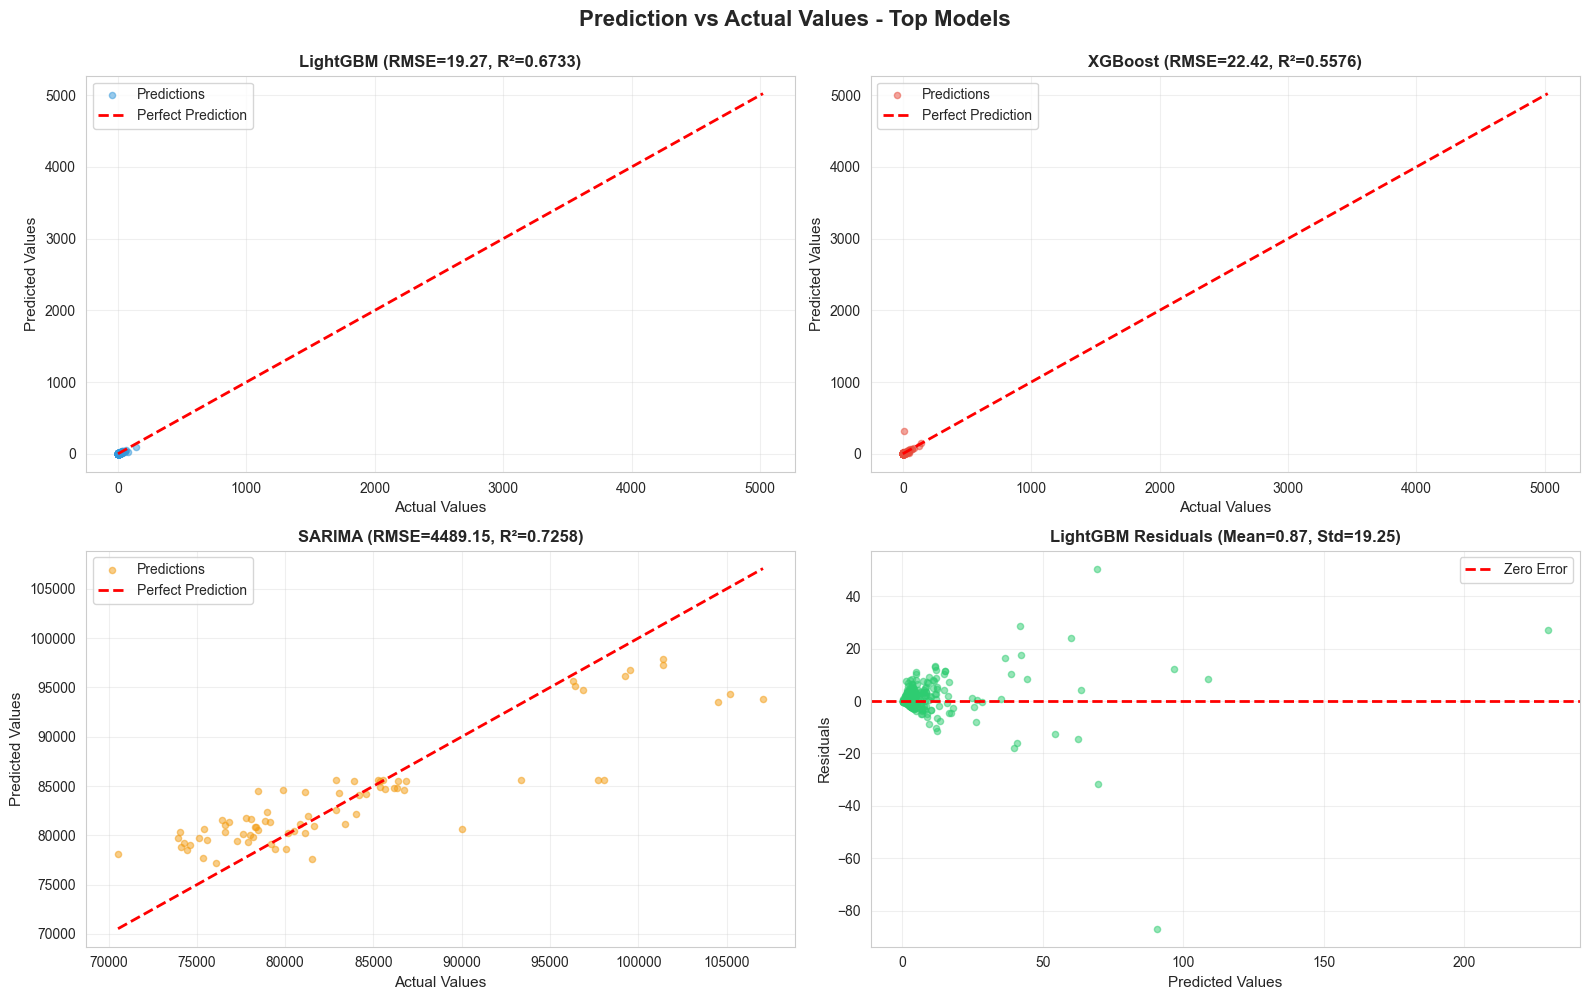

✓ Prediction vs Actual visualization saved to prediction_vs_actual.png


In [24]:
# Create prediction vs actual visualizations for top models
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Prediction vs Actual Values - Top Models', fontsize=16, fontweight='bold', y=0.995)

# Get test set actual values (in original scale)
y_test_original = np.expm1(y_test.values)

# 1. LightGBM
ax1 = axes[0, 0]
lgb_pred_original = np.expm1(np.maximum(lgb_pred, 0))
sample_indices_lgb = np.random.choice(len(y_test_original), min(500, len(y_test_original)), replace=False)
sample_indices_lgb = np.sort(sample_indices_lgb)

ax1.scatter(y_test_original[sample_indices_lgb], lgb_pred_original[sample_indices_lgb], 
           alpha=0.5, s=20, label='Predictions', color='#3498db')
min_val, max_val = min(y_test_original.min(), lgb_pred_original.min()), max(y_test_original.max(), lgb_pred_original.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Values', fontsize=11)
ax1.set_ylabel('Predicted Values', fontsize=11)
ax1.set_title(f'LightGBM (RMSE={lgb_rmse:.2f}, R²={lgb_r2:.4f})', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. XGBoost
ax2 = axes[0, 1]
xgb_pred_original = np.expm1(np.maximum(xgb_pred, 0))
sample_indices_xgb = np.random.choice(len(y_test_original), min(500, len(y_test_original)), replace=False)
sample_indices_xgb = np.sort(sample_indices_xgb)

ax2.scatter(y_test_original[sample_indices_xgb], xgb_pred_original[sample_indices_xgb], 
           alpha=0.5, s=20, label='Predictions', color='#e74c3c')
min_val, max_val = min(y_test_original.min(), xgb_pred_original.min()), max(y_test_original.max(), xgb_pred_original.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax2.set_xlabel('Actual Values', fontsize=11)
ax2.set_ylabel('Predicted Values', fontsize=11)
ax2.set_title(f'XGBoost (RMSE={xgb_rmse:.2f}, R²={xgb_r2:.4f})', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. SARIMA (handle smaller sample size)
ax3 = axes[1, 0]
sarima_sample_size = min(100, len(sarima_test_series))  # Use appropriate sample size
sample_indices_sarima = np.random.choice(len(sarima_test_series), sarima_sample_size, replace=False)
sample_indices_sarima = np.sort(sample_indices_sarima)

ax3.scatter(sarima_test_series.values[sample_indices_sarima], sarima_pred[sample_indices_sarima], 
           alpha=0.5, s=20, label='Predictions', color='#f39c12')
min_val, max_val = min(sarima_test_series.values.min(), sarima_pred.min()), max(sarima_test_series.values.max(), sarima_pred.max())
ax3.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax3.set_xlabel('Actual Values', fontsize=11)
ax3.set_ylabel('Predicted Values', fontsize=11)
ax3.set_title(f'SARIMA (RMSE={sarima_rmse:.2f}, R²={sarima_r2:.4f})', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Residuals for LightGBM (best model)
ax4 = axes[1, 1]
residuals = y_test_original - lgb_pred_original
sample_indices_res = np.random.choice(len(residuals), min(500, len(residuals)), replace=False)
sample_indices_res = np.sort(sample_indices_res)

ax4.scatter(lgb_pred_original[sample_indices_res], residuals[sample_indices_res], 
           alpha=0.5, s=20, color='#2ecc71')
ax4.axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Error')
ax4.set_xlabel('Predicted Values', fontsize=11)
ax4.set_ylabel('Residuals', fontsize=11)
ax4.set_title(f'LightGBM Residuals (Mean={residuals.mean():.2f}, Std={residuals.std():.2f})', 
             fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('trained_models/prediction_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Prediction vs Actual visualization saved to prediction_vs_actual.png")

## 12. Error Distribution & Model Ranking

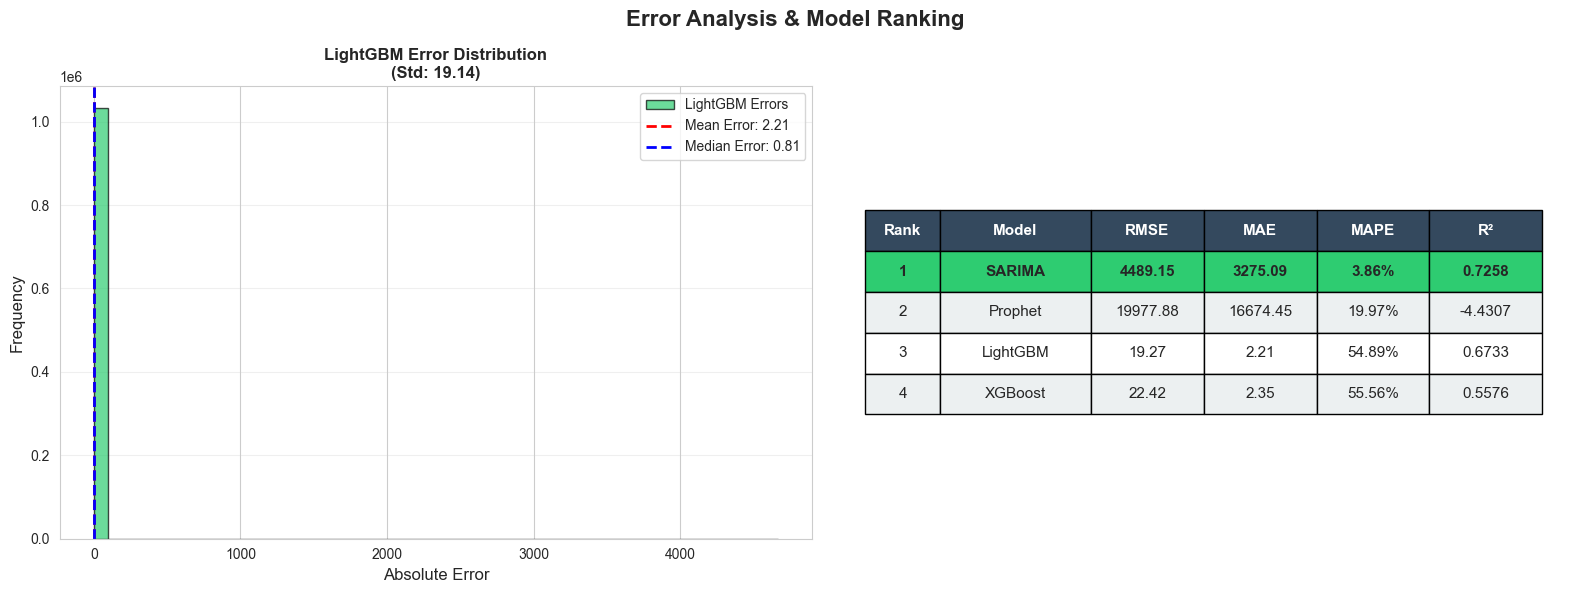

✓ Error analysis and ranking visualization saved to error_analysis_ranking.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Error Analysis & Model Ranking', fontsize=16, fontweight='bold')

# 1. Error Distribution for LightGBM
ax1 = axes[0]
lgb_errors = np.abs(y_test_original - lgb_pred_original)
ax1.hist(lgb_errors, bins=50, color='#2ecc71', alpha=0.7, edgecolor='black', label='LightGBM Errors')
ax1.axvline(lgb_errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean Error: {lgb_errors.mean():.2f}')
ax1.axvline(np.median(lgb_errors), color='blue', linestyle='--', linewidth=2, label=f'Median Error: {np.median(lgb_errors):.2f}')
ax1.set_xlabel('Absolute Error', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title(f'LightGBM Error Distribution\n(Std: {lgb_errors.std():.2f})', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3, axis='y')

# 2. Model Ranking Dashboard
ax2 = axes[1]
ax2.axis('off')

# Create ranking table
ranking_data = []
for rank, (idx, row) in enumerate(results_df_sorted.iterrows(), 1):
    ranking_data.append([
        f"{rank}",
        row['Model'],
        f"{row['RMSE']:.2f}" if not np.isnan(row['RMSE']) else 'N/A',
        f"{row['MAE']:.2f}" if not np.isnan(row['MAE']) else 'N/A',
        f"{row['MAPE%']:.2f}%" if not np.isnan(row['MAPE%']) else 'N/A',
        f"{row['R2']:.4f}" if not np.isnan(row['R2']) else 'N/A'
    ])

table = ax2.table(
    cellText=ranking_data,
    colLabels=['Rank', 'Model', 'RMSE', 'MAE', 'MAPE', 'R²'],
    cellLoc='center',
    loc='center',
    colWidths=[0.1, 0.2, 0.15, 0.15, 0.15, 0.15]
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(6):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style rows
for i in range(1, len(ranking_data) + 1):
    if i == 1:  # Winner row
        for j in range(6):
            table[(i, j)].set_facecolor('#2ecc71')
            table[(i, j)].set_text_props(weight='bold')
    else:
        for j in range(6):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#ecf0f1')
            else:
                table[(i, j)].set_facecolor('#ffffff')

plt.tight_layout()
plt.savefig('trained_models/error_analysis_ranking.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Error analysis and ranking visualization saved to error_analysis_ranking.png")